In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import warnings, time
warnings.filterwarnings('ignore')

In [54]:
df = pd.read_csv("TS (1) (1).csv")
df['Time'] = pd.to_datetime(df['Time'], format='%m/%d/%y %H:%M')
df = df.set_index('Time').sort_index()
df.columns = ['Users']
df = df.asfreq('H')
df['Users'] = df['Users'].interpolate(method='time').ffill().bfill()

df.loc[df['Users'] < 1000, 'Users'] = np.nan
df['Users'] = df['Users'].interpolate(method='time').ffill().bfill()

cutoff = df.index.max() - pd.Timedelta(days=30)
train = df[df.index <= cutoff].copy()
test  = df[df.index >  cutoff].copy()

In [55]:
def evaluate(name, actual, pred, train_time=0):
    mae   = mean_absolute_error(actual, pred)
    rmse  = np.sqrt(mean_squared_error(actual, pred))
    r2    = r2_score(actual, pred)
    denom = (np.abs(actual) + np.abs(pred)) / 2
    smape = np.mean(np.where(denom == 0, 0, np.abs(actual - pred) / denom)) * 100
    mape  = np.mean(np.abs((actual - pred) / actual)) * 100
    return {
        'Модель': name,
        'R²': r2,
        'MAE': mae,
        'RMSE': rmse,
        'SMAPE %': smape,
        'MAPE %': mape,
        'Время (с)': train_time,
        '_pred': pred
    }

results = []
actual = test['Users'].values

In [56]:
from statsmodels.tsa.arima.model import ARIMA
t0 = time.time()
try:
    model_arima = ARIMA(train['Users'], order=(24, 1, 2)).fit()
    pred_arima = model_arima.forecast(steps=len(test)).clip(lower=0).values
    t_arima = time.time() - t0
    results.append(evaluate('ARIMA', actual, pred_arima, t_arima))
except Exception as e:
    print(f"  Ошибка: {e}")

In [57]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
t0 = time.time()
try:
    model_sarima = SARIMAX(
        train['Users'],
        order=(1, 1, 1),
        seasonal_order=(1, 0, 1, 24),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False, cov_type='none')
    pred_sarima = model_sarima.forecast(steps=len(test)).clip(lower=0).values
    t_sarima = time.time() - t0
    results.append(evaluate('SARIMA', actual, pred_sarima, t_sarima))
except Exception as e:
    print(f"  Ошибка: {e}")

In [58]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
print("\n[3/5] Holt-Winters (add/add, m=24)...")
t0 = time.time()
try:
    model_hw = ExponentialSmoothing(
        train['Users'],
        trend='add', seasonal='add', seasonal_periods=24,
        initialization_method='estimated'
    ).fit()
    pred_hw = model_hw.forecast(len(test)).clip(lower=0).values
    t_hw = time.time() - t0
    results.append(evaluate('Holt-Winters', actual, pred_hw, t_hw))
except Exception as e:
    print(f"  Ошибка: {e}")


[3/5] Holt-Winters (add/add, m=24)...


In [59]:
def build_features(data):
    X = pd.DataFrame(index=data.index)
    y = data['Users']

    X['hour']       = data.index.hour
    X['dayofweek']  = data.index.dayofweek
    X['is_weekend'] = (data.index.dayofweek >= 5).astype(int)
    X['hour_sin']   = np.sin(2 * np.pi * data.index.hour / 24)
    X['hour_cos']   = np.cos(2 * np.pi * data.index.hour / 24)
    X['dow_sin']    = np.sin(2 * np.pi * data.index.dayofweek / 7)
    X['dow_cos']    = np.cos(2 * np.pi * data.index.dayofweek / 7)

    for lag in [1, 2, 3, 24, 25, 48, 168]:
        X[f'lag_{lag}'] = y.shift(lag)

    X['roll_24_mean']  = y.shift(1).rolling(24).mean()
    X['roll_24_std']   = y.shift(1).rolling(24).std()
    X['roll_168_mean'] = y.shift(1).rolling(168).mean()
    X['roll_168_max']  = y.shift(1).rolling(168).max()
    X['roll_168_min']  = y.shift(1).rolling(168).min()
    X['trend']         = X['roll_24_mean'] / (X['roll_168_mean'] + 1)

    return X, y

X_all, y_all = build_features(df)
valid = ~X_all.isna().any(axis=1) & ~y_all.isna()
X_all, y_all = X_all[valid], y_all[valid]

train_mask = X_all.index <= cutoff
X_tr, y_tr = X_all[train_mask], y_all[train_mask]
X_te, y_te = X_all[~train_mask], y_all[~train_mask]

In [60]:
t0 = time.time()
rf = RandomForestRegressor(
    n_estimators=300, max_depth=20, min_samples_leaf=2,
    n_jobs=-1, random_state=42
)
rf.fit(X_tr, y_tr)
pred_rf = rf.predict(X_te).clip(min=0)
t_rf = time.time() - t0
results.append(evaluate('Random Forest', y_te.values, pred_rf, t_rf))

In [61]:
t0 = time.time()
gb = GradientBoostingRegressor(
    n_estimators=1000, learning_rate=0.05, max_depth=6,
    subsample=0.8, random_state=42
)
gb.fit(X_tr, y_tr)
pred_gb = gb.predict(X_te).clip(min=0)
t_gb = time.time() - t0
results.append(evaluate('Gradient Boosting', y_te.values, pred_gb, t_gb))

In [62]:
res_df = pd.DataFrame([{k: v for k, v in r.items() if k != '_pred'} for r in results])
res_df = res_df.sort_values('R²', ascending=False).reset_index(drop=True)
res_df['R²']       = res_df['R²'].round(4)
res_df['MAE']      = res_df['MAE'].round(0).astype(int)
res_df['RMSE']     = res_df['RMSE'].round(0).astype(int)
res_df['SMAPE %']  = res_df['SMAPE %'].round(2)
res_df['MAPE %']   = res_df['MAPE %'].round(2)
res_df['Время (с)'] = res_df['Время (с)'].round(1)
print(res_df.to_string(index=False))

                 Модель      R²   MAE  RMSE  SMAPE %  MAPE %  Время (с)
          Random Forest  0.9165  1691  2569     6.60   11.14        5.4
      Gradient Boosting  0.8996  1741  2817     6.67   12.96       20.9
           ARIMA(2,1,2)  0.3550  5520  7139    17.95   28.17       64.8
SARIMA(1,1,1)(1,0,1,24) -3.1973 15849 18211    78.01   57.01        4.1
           Holt-Winters -3.8939 18061 19664   100.23   67.86        0.5


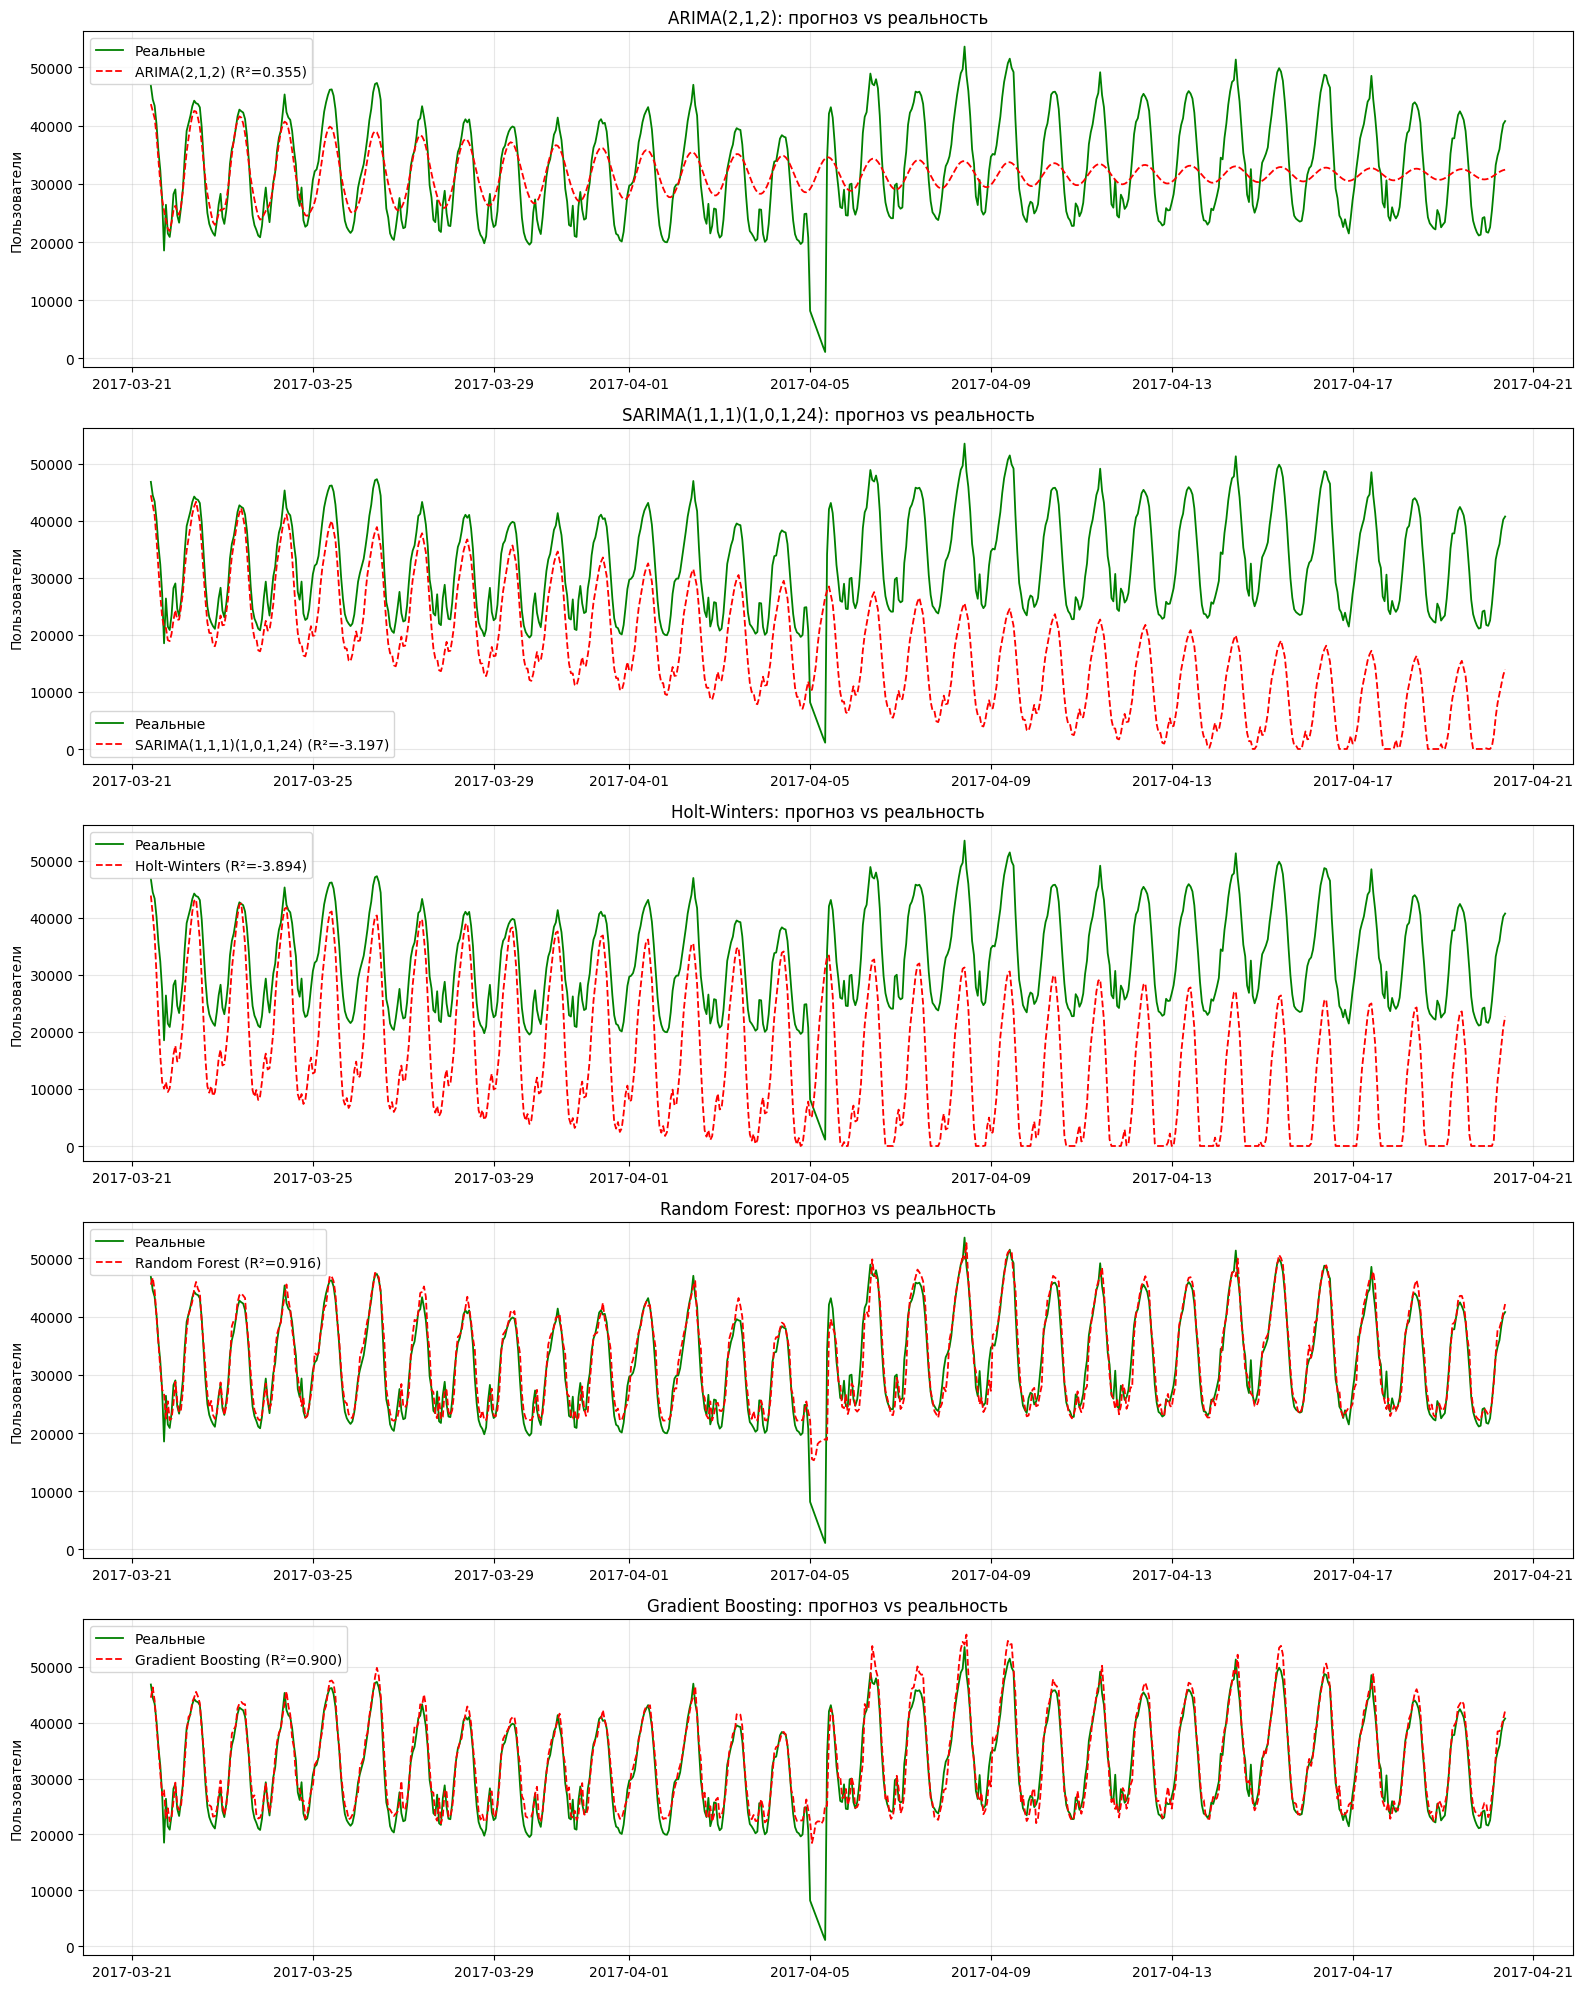

In [63]:
fig, axes = plt.subplots(len(results), 1, figsize=(16, 4 * len(results)))
if len(results) == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    pred = r['_pred']
    if len(pred) == len(test):
        idx = test.index
        real = test['Users'].values
    else:
        idx = y_te.index
        real = y_te.values

    ax.plot(idx, real, color='green', linewidth=1.3, label='Реальные')
    ax.plot(idx, pred, color='red', linewidth=1.3, linestyle='--',
            label=f"{r['Модель']} (R²={r['R²']:.3f})")
    ax.set_title(f"{r['Модель']}: прогноз vs реальность", fontsize=12)
    ax.set_ylabel("Пользователи")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

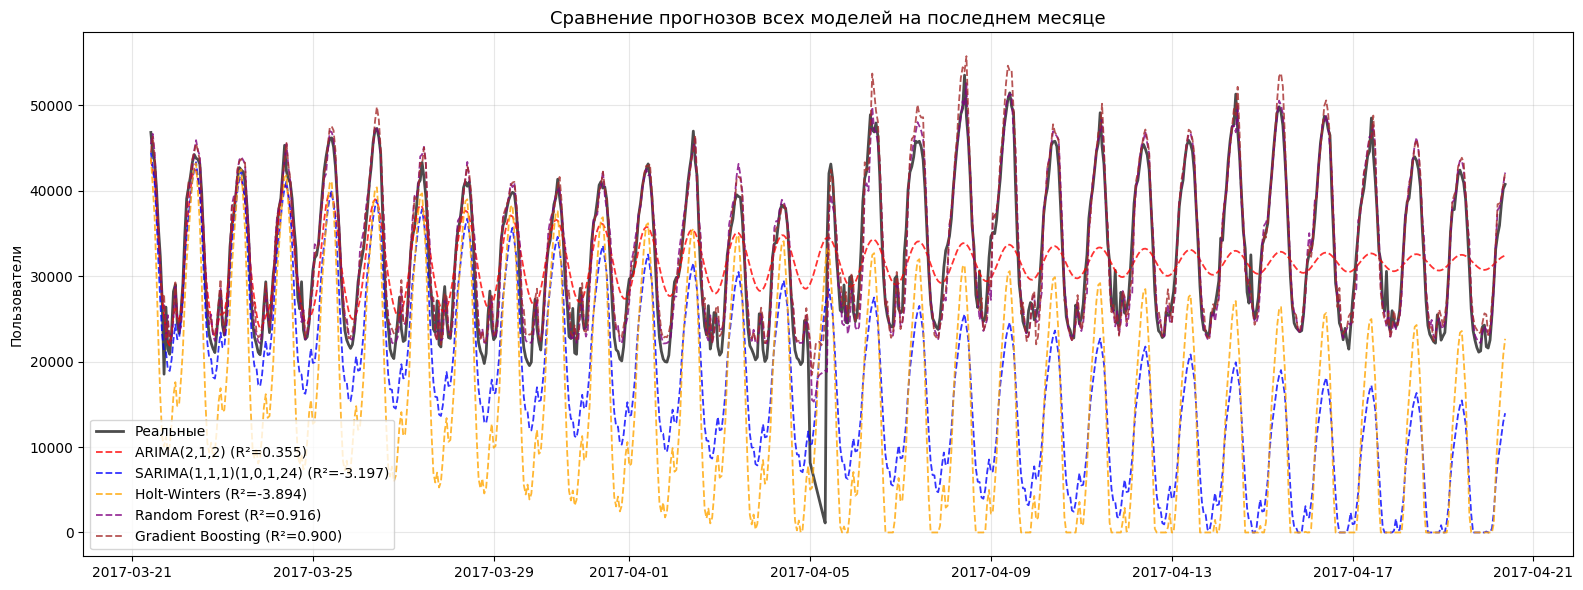

In [64]:
plt.figure(figsize=(16, 6))
plt.plot(y_te.index, y_te.values, color='black', linewidth=2, label='Реальные', alpha=0.7)

colors = ['red', 'blue', 'orange', 'purple', 'brown']
for r, c in zip(results, colors):
    pred = r['_pred']
    if len(pred) == len(test):
        plt.plot(test.index, pred, linestyle='--', linewidth=1.3,
                 color=c, alpha=0.8, label=f"{r['Модель']} (R²={r['R²']:.3f})")
    else:
        plt.plot(y_te.index, pred, linestyle='--', linewidth=1.3,
                 color=c, alpha=0.8, label=f"{r['Модель']} (R²={r['R²']:.3f})")

plt.title("Сравнение прогнозов всех моделей на последнем месяце", fontsize=13)
plt.ylabel("Пользователи")
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [65]:
best = max(results, key=lambda r: r['R²'])
print(f"ЛУЧШАЯ МОДЕЛЬ: {best['Модель']}")
print(f"  R²    = {best['R²']:.4f}")
print(f"  MAE   = {best['MAE']:,.0f}")
print(f"  RMSE  = {best['RMSE']:,.0f}")
print(f"  SMAPE = {best['SMAPE %']:.2f}%")
print(f"  MAPE  = {best['MAPE %']:.2f}%")

ЛУЧШАЯ МОДЕЛЬ: Random Forest
  R²    = 0.9165
  MAE   = 1,691
  RMSE  = 2,569
  SMAPE = 6.60%
  MAPE  = 11.14%
